# 캐글 로그인

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

# 캐글에서 토큰 받으셔서 로그인 하셔야 합니다.

Kaggle credentials set.
Kaggle credentials successfully validated.


# 캐글에서 데이터 불러오기

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

stanford_rna_3d_folding_path = kagglehub.competition_download('stanford-rna-3d-folding')
metric_usalign_path = kagglehub.dataset_download('metric/usalign')
geraseva_protenix_checkpoints_path = kagglehub.dataset_download('geraseva/protenix-checkpoints')
metric_ribonanza_tm_score_path = kagglehub.notebook_output_download('metric/ribonanza-tm-score')

print('Data source import complete.')

100%|██████████| 213M/213M [00:02<00:00, 98.4MB/s]

Extracting files...


Extracting files...
Data source import complete.


# 모델-라이브러리 설치

In [ ]:
# ——————————————————————————
# 1) 모델·라이브러리 설치
# ——————————————————————————
!pip install --no-deps protenix biopython ml-collections biotite==1.0.1 rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 65.0 MB/s eta 0:00:00


# 환경변수 - 심볼릭 링크 설정

In [ ]:
# ——————————————————————————
# 2) 환경변수·심볼릭 링크 설정
# ——————————————————————————
import os, sys

# Protenix 체크포인트 경로 (kagglehub로 풀린 로컬 폴더)
os.environ['PROTENIX_DATA_ROOT_DIR'] = '/kaggle/input/protenix-checkpoints'

# USalign 복사 및 실행 권한
print(">> metric_usalign_path =", metric_usalign_path)
!ls "$metric_usalign_path"

!mkdir -p /content/USalign-bin
!cp "$metric_usalign_path/USalign" /content/USalign-bin/
!chmod +x /content/USalign-bin/USalign

USALIGN = '/content/USalign-bin/USalign'

# RhoFold 모듈 경로 (필요하다면)
RHONET_DIR = '/kaggle/input/data-for-demo-for-rhofold-plus-with-kaggle-msa/RhoFold-main'
sys.path.append(RHONET_DIR)

>> metric_usalign_path = /kaggle/input/usalign
USalign


# 공통 임포트 및 헬퍼 정의

In [ ]:
# ——————————————————————————
# 3) 공통 임포트 및 헬퍼 정의
# ——————————————————————————
import time
time0 = time.time()

import numpy as np
import pandas as pd
import torch
import Bio
from Bio.PDB import PDBParser
from tqdm import tqdm

# DataFrame → PDB 변환 헬퍼
def write_target_line(atom_name, atom_serial, residue_name, residue_num, x, y, z):
    return f"ATOM  {atom_serial:>5d}  {atom_name:<5s} {residue_name:<3s} {residue_num:>4d}    {x:>8.3f}{y:>8.3f}{z:>8.3f}  1.00  0.00           C\n"

def write_xyz_to_pdb(df, out_path, xyz_col_id=1):
    cnt=0
    with open(out_path,'w') as f:
        for _, r in df.iterrows():
            x,y,z = r[f'x_{xyz_col_id}'], r[f'y_{xyz_col_id}'], r[f'z_{xyz_col_id}']
            if not np.isnan(x+y+z):
                cnt+=1
                f.write(write_target_line("C1'", int(r.resid), r.resname, int(r.resid), x,y,z))
    return cnt

def parse_usalign_for_tm_score(text):
    m = re.findall(r"TM-score=\s*([\d.]+)", text)
    return float(m[1])  # 두 번째 값

def call_usalign(pred_df, truth_df):
    pred_pdb = '/tmp/pred.pdb'
    truth_pdb = '/tmp/truth.pdb'
    write_xyz_to_pdb(pred_df, pred_pdb)
    write_xyz_to_pdb(truth_df, truth_pdb)
    cmd = f"{USALIGN} {pred_pdb} {truth_pdb} -atom \" C1'\" -m -"
    out = os.popen(cmd).read()
    tm = parse_usalign_for_tm_score(out)
    return tm

In [ ]:
# ——————————————————————————
# 4) Protenix Inference 세팅
# ——————————————————————————
from runner.batch_inference import get_default_runner
from runner.inference import update_inference_configs, InferenceRunner
from protenix.data.infer_data_pipeline import InferenceDataset
from configs.configs_base import configs as configs_base
from configs.configs_data import data_configs
from configs.configs_inference import inference_configs
from protenix.config.config import parse_configs

configs_base["use_deepspeed_evo_attention"] = False

# 시드 고정
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

# 커스텀 Dataset
class DictDataset(InferenceDataset):
    def __init__(self, seq_list: list, dump_dir: str, id_list: list = None, use_msa: bool = False) -> None:
        # 필수 속성들
        self.dump_dir = dump_dir
        self.use_msa  = use_msa

        # inputs 구성
        if id_list is None:
            self.inputs = [
                {"sequences":[{"rnaSequence":{"sequence": seq, "count":1}}], "name":"query"}
                for seq in seq_list
            ]
        else:
            self.inputs = [
                {"sequences":[{"rnaSequence":{"sequence": seq, "count":1}}], "name":tid}
                for seq, tid in zip(seq_list, id_list)
            ]

# configs 조정 (Validation 전용)
# 디퓨전 모델 파라미터 세팅
configs_base["sample_diffusion"]["N_sample"] = 1 # 생성할 샘플 수
configs_base["sample_diffusion"]["N_step"] = 150 # Diffusion 노이즈 제거 스텝 수
configs_base["model"]["N_cycle"] = 10 # Evoformer 반복 횟수
inference_configs['load_checkpoint_path'] = '/kaggle/input/protenix-checkpoints/model_v0.2.0.pt'

# 1) 다운로드된 경로 확인
print("Protenix checkpoints path:", geraseva_protenix_checkpoints_path)
!ls "$geraseva_protenix_checkpoints_path"

# 2) configs 에 실제 경로로 지정
import os
inference_configs['load_checkpoint_path'] = os.path.join(
    geraseva_protenix_checkpoints_path, 'model_v0.2.0.pt'
)

# 3) 그리고 나서 Runner 초기화
configs = {**configs_base, **{"data": data_configs}, **inference_configs}
configs = parse_configs(configs=configs, fill_required_with_null=True)
runner = InferenceRunner(configs)

Protenix checkpoints path: /kaggle/input/protenix-checkpoints
components.v20240608.cif		model_v0.2.0.pt
components.v20240608.cif.rdkit_mol.pkl


2025-04-28 07:47:17,789 [/usr/local/lib/python3.11/dist-packages/runner/inference.py:159] INFO runner.inference: Distributed environment: world size: 1, global rank: 0, local rank: 0
2025-04-28 07:47:17,813 [/usr/local/lib/python3.11/dist-packages/runner/inference.py:65] INFO root: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2025-04-28 07:47:17,888 [/usr/local/lib/python3.11/dist-packages/runner/inference.py:89] INFO root: Finished init ENV.


train scheduler 16.0
inference scheduler 16.0
Diffusion Module has 16.0


2025-04-28 07:47:23,835 [/usr/local/lib/python3.11/dist-packages/runner/inference.py:159] INFO runner.inference: Loading from /kaggle/input/protenix-checkpoints/model_v0.2.0.pt, strict: True
2025-04-28 07:47:31,787 [/usr/local/lib/python3.11/dist-packages/runner/inference.py:159] INFO runner.inference: Sampled key: module.input_embedder.atom_attention_encoder.linear_no_bias_f.weight
2025-04-28 07:47:32,061 [/usr/local/lib/python3.11/dist-packages/runner/inference.py:159] INFO runner.inference: Finish loading checkpoint.


In [ ]:
import logging

# 전체 로그를 WARNING 이상만 출력
logging.getLogger().setLevel(logging.WARNING)

# 또는 protenix / runner 모듈만 선택적으로 조절
logging.getLogger('protenix.data.infer_data_pipeline').setLevel(logging.ERROR)
logging.getLogger('runner.inference').setLevel(logging.ERROR)

In [ ]:
# 1) CCD 캐시 디렉터리 생성
!mkdir -p /usr/local/lib/python3.11/dist-packages/release_data/ccd_cache/

# 2) 체크포인트 데이터셋에서 CIF & PKL 파일을 복사
!cp "{geraseva_protenix_checkpoints_path}/components.v20240608.cif" \
      "/usr/local/lib/python3.11/dist-packages/release_data/ccd_cache/"

!cp "{geraseva_protenix_checkpoints_path}/components.v20240608.cif.rdkit_mol.pkl" \
      "/usr/local/lib/python3.11/dist-packages/release_data/ccd_cache/"

100%|██████████| 12/12 [25:15<00:00, 126.31s/it]

target_id  seq_length  protenix_tm
    R1107          69      0.26790
    R1108          69      0.25312
    R1116         157      0.43374
  R1117v2          30      0.11952
    R1126         363      0.50728
    R1128         238      0.45315
    R1136         374      0.44248
    R1138         720      0.54383
    R1149         124      0.26239
    R1156         135      0.31435
    R1189         118      0.33730
    R1190         118      0.31804

Validation Average TM-score (Best-of-5): 0.354425


<Axes: >

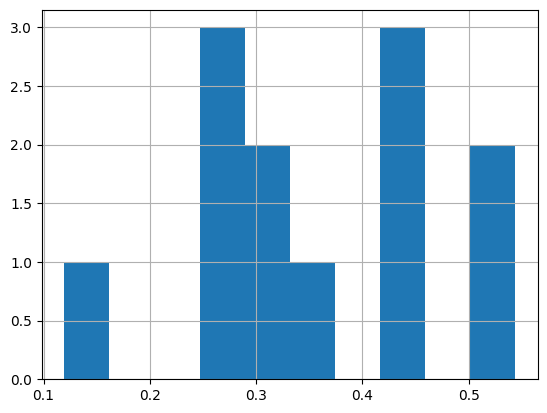

In [ ]:
import logging
import warnings
import os
import pandas as pd
import numpy as np
import time
from tqdm import tqdm
import re

# 1) 로그 레벨 조정
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger('protenix.data.infer_data_pipeline').setLevel(logging.ERROR)
logging.getLogger('runner.inference').setLevel(logging.ERROR)

# 2) AMP FutureWarning 무시
warnings.filterwarnings("ignore", category=FutureWarning)

# 3) Best-of-5 샘플링 설정
configs_base["sample_diffusion"]["N_sample"] = 5 # 디퓨전 모델로 예측 값을 몇개 만들지 설정.

# 4) 데이터 경로
root = stanford_rna_3d_folding_path
val_seq_csv   = os.path.join(root, 'validation_sequences.csv')
val_label_csv = os.path.join(root, 'validation_labels.csv')

# 5) 데이터 로드
val_seq_df   = pd.read_csv(val_seq_csv)
val_label_df = pd.read_csv(val_label_csv)
val_label_df['target_id'] = val_label_df['ID'].str.rsplit('_', n=1).str[0]

# 6) 결과 칼럼 및 Dataset 준비
val_seq_df['protenix_tm']   = np.nan
val_seq_df['seq_length']    = val_seq_df['sequence'].str.len()
dataset = DictDataset(
    seq_list=val_seq_df.sequence.tolist(),
    dump_dir='output_val',
    id_list=val_seq_df.target_id.tolist(),
    use_msa=False
)

# 7) 검증 루프 (Best-of-5 TM-score) # 5개 예측값 중에서 가장 점수가 높은 걸 선택하는 방식.
start = time.time()
for i, row in tqdm(val_seq_df.iterrows(), total=len(val_seq_df)):
    seq = row.sequence
    tid = row.target_id

    # truth_df 구성
    raw = val_label_df[val_label_df.target_id == tid].copy()
    raw['resid']   = raw['ID'].str.rsplit('_', n=1).str[1].astype(int)
    raw['resname'] = raw['resid'].apply(lambda r: seq[r-1])
    raw = raw.rename(columns={'x':'x_1','y':'y_1','z':'z_1'})
    truth_df = raw[['resname','resid','x_1','y_1','z_1']]

    # 스킵 조건
    # if len(seq) > 300 or truth_df.shape[0] < 3: # 300보다 길면 추론 스킵. 일단 동작을 확인하기 위해서 빠른 실행 목적.
    #     continue
    if truth_df.shape[0] < 3: continue # 스킵 없이 전부 추론

    # featurizing
    data, _, err = dataset[i]
    if err:
        continue

    # 모델 구성 업데이트 및 예측
    new_cfg = update_inference_configs(configs, data["N_token"].item())
    runner.update_model_configs(new_cfg)
    coords = runner.predict(data)['coordinate'][
        :, data['input_feature_dict']['atom_to_tokatom_idx'] == 12
    ]  # shape: [5, L, 3]

    # Best-of-5 TM-score 계산
    best_tm = -1.0
    for k in range(coords.shape[0]):
        pred_k = coords[k]
        pred_df_k = pd.DataFrame([
            {
                "resname": seq[j],
                "resid":   j+1,
                "x_1":     float(pred_k[j,0]),
                "y_1":     float(pred_k[j,1]),
                "z_1":     float(pred_k[j,2])
            }
            for j in range(len(seq))
        ])
        try:
            tm_k = call_usalign(pred_df_k, truth_df)
            best_tm = max(best_tm, tm_k)
        except:
            pass

    if best_tm >= 0:
        val_seq_df.at[i, 'protenix_tm'] = best_tm

    # 시간 제한
    if time.time() - start > (12*3600 - 300):
        break

# 8) 개별 시퀀스 결과 출력 & 저장
results = val_seq_df[['target_id', 'seq_length', 'protenix_tm']]
print(results.to_string(index=False))
results.to_csv('validation_tm_scores_per_sequence.csv', index=False)

# 9) 전체 평균 및 분포 시각화
print("\nValidation Average TM-score (Best-of-5):",
      val_seq_df['protenix_tm'].mean())
val_seq_df['protenix_tm'].hist()